<a href="https://colab.research.google.com/github/NikitaMarnykh/labor_market_analysis/blob/main/%D0%9C%D0%B0%D1%80%D0%BD%D1%8B%D1%85_%D0%9D_%D0%92_%D0%B8_%D0%9E%D0%B1%D0%BE%D1%80%D0%BE%D1%82%D0%BE%D0%B2_%D0%9C_%D0%92_%D1%80%D1%8B%D0%BD%D0%BE%D0%BA_%D1%82%D1%80%D1%83%D0%B4%D0%B0_%D0%BF%D1%80%D0%B5%D0%B4%D0%BE%D0%B1%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%BA%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Постановка задачи и описание датасета

Перед Департаментом труда и занятости населения Томской области стоит задача
– в течение полугода разработать эффективные стратегии управления
персоналом, образования и подготовки кадров в целях увеличения уровня
занятости в регионе на 2 процентных пункта. Для этого специалистам необходимо
лучше понять особенности функционирования рынка труда, а именно: в какие
города области и какие специалисты требуются, какими ключевыми навыками они
должны обладать, какие условия труда предлагают работодатели, есть ли
возможность трудоустроиться соискателям с инвалидностью.
Специалистами Роснавыка были представлены датасеты с выгруженной
информацией по региону.

**Задачи:**

  - Необходимо проанализировать вакансии, доступные для соискателей с
инвалидностью (какие профессии требуются, в каких городах больше всего
предложений, какие требования предъявляют работодатели, какие условия труда
предлагают)

  - Проанализируйте вакансии региона (на какие
специальности и в каких городах наибольший спрос, какие требования
предъявляют работодатели, какие условия труда предлагают) (датасет
hh_hard.csv) MEDIUM

  - Необходимо проанализировать вакансии региона и выявить значимые
взаимосвязи между признаками (на какие специальности и в каких городах
наибольший спрос, какие требования предъявляют работодатели, какие условия
труда предлагают, от чего зависит уровень заработной платы и другие условия
труда)

  - Проанализируйте ключевые навыки в самой популярной сфере/сферах в регионе и выявить значимые взаимосвязи между признаками (на какие навыки и в каких городах наибольший спрос, есть ли взаимосвязь между навыками и требованиями к соискателям, как тот или иной навык влияет на условия труда) (датасет hh_hard.csv)

  - построить регрессионную модель для предсказания уровня заработной платы.

  - Представьте аналитический отчет содержащий выводы и рекомендации для Заказчика, которые помогут ему для решения его бизнес-задач.

**Исходные данные:**

  - идентификатор вакансии (id)

  - наименование вакансии (name)

  - профессиональная роль (professional roles)

  - регион (area), в т.ч. страна (country), регион (region), округ (district), город(city)

  - заработная плата (salary), в т.ч. минимальная заработная плата (salary_from),
максимальная заработная плата (salary_to)

  - опыт работы (experience): 0 – без опыта, 1-3 – от 1 до 3 лет, 3-6 – от 3 до 6 лет, 6- - от 6 лет

  - график работы (schedule): full_day – полный день, remote – удаленная работа,
  flexible – гибкий график, shift – сменный график, labor - вахтовый метод

  - тип занятости (employment): full – полная занятость, part – частичная
занятость, project – проектная работа, probation - стажировка

  - наименование работодателя (employer)

  - доступна ли вакансия для соискателей с инвалидностью (accept_handicapped): True – доступна, False - недоступна

  - ключевые навыки (key_skills)

**Датасет в формате csv по ссылке:**

  - https://disk.yandex.ru/d/OYP_n5bYz_ExzA


## 2. Установка и подключение зависимостей для предобработки

Устанавливаем все необходимые зависимости

In [1]:
!pip install numpy
!pip install matplotlib
!pip install pandas
!pip install seaborn
!pip install scikit-learn
!pip install missingno

Подключаем все необходимые зависимости

In [2]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

import re

import json

import ast

import missingno as msno

from sklearn.impute import KNNImputer

Подгружаем репозиторий для работы с ним

In [3]:
!git clone https://github.com/NikitaMarnykh/labor_market_analysis

Cloning into 'labor_market_analysis'...
remote: Enumerating objects: 52, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 52 (delta 30), reused 10 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (52/52), 26.20 MiB | 6.04 MiB/s, done.
Resolving deltas: 100% (30/30), done.


Перейдём в установленный репозиторий

In [4]:
%cd labor_market_analysis/

/content/labor_market_analysis


## 3. Первичный обзор датасета. Оценка размеров датасета, наличия дубликатов и пропусков

Сохраняем датасет в переменную

In [5]:
dataset = pd.read_csv('hh_hard.csv',
                      na_values=['NA', 'N/A', 'null', 'missing', '-', '?', '...'],
                      keep_default_na=True,
                      na_filter=True)

Проведём обзор содержимого таблицы

In [6]:
dataset.head(15)

,id,name,professional_roles,experience,schedule,employment,employer,accept_handicapped,key_skills,area,salary
0,72121675,"Инженер-конструктор (в г. Электрогорск, Москов...","Инженер-конструктор, инженер-проектировщик",1-3,full_day,full,Стройкомплектсервис,False,"['ANSYS', 'AutoCAD', 'Autodesk Inventor', 'Sol...","{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":75000.0,""salary_to"":100000.0}"
1,72121730,Специалист по доставке (Подработка),Курьер,0,shift,part,Квазар,False,['Грамотная речь'],"{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":60000.0,""salary_to"":110000.0}"
2,72122239,Удаленный оператор ПК / сотрудник на ввод данных,"Менеджер по продажам, менеджер по работе с кли...",0,remote,part,Staff-Linear,True,"['Грамотная речь', 'Базовые знания ПК']","{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":25000.0,""salary_to"":50000.0}"
3,72123219,Повар линии раздачи,"Официант, бармен, бариста",0,shift,full,AYS GROUP,False,"['Грамотная речь', 'Грамотная речь', 'Работа в...","{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":null,""salary_to"":35000.0}"
4,72123390,Повар в магазин SPAR (ул.Киевская 139),"Повар, пекарь, кондитер",0,full_day,full,"ЛАМА, Группа компаний",False,"['Коммуникативная грамотность', 'Обучаемость и...","{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":28000.0,""salary_to"":36000.0}"
5,72124633,Дефектоскопист,Технолог,1-3,full_day,full,Деталь Проект,False,"['Ведение документооборота', 'Базовые знания П...","{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":60000.0,""salary_to"":60000.0}"
6,72124864,Водитель-кладовщик,Водитель,0,full_day,full,Автоцентр АВТОГИК,False,"['Базовые знания ПК', 'Коммуникативная грамотн...","{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":35000.0,""salary_to"":85000.0}"
7,72125286,Электромонтер,Электромонтажник,3-6,labor,full,Эко-Системы,False,"['Монтаж металлоконструкций', 'Выполнение стро...","{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":100000.0,""salary_to"":150000.0}"
8,72125786,Менеджер по продажам,"Менеджер по продажам, менеджер по работе с кли...",1-3,full_day,full,"Мототека, филиал г.Томск",False,"['Продажи', 'Коммуникативная грамотность', 'Гр...","{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":40000.0,""salary_to"":95000.0}"
9,72125979,Менеджер по продажам,Агент по недвижимости,0,full_day,full,ДомПлюс,False,"['Продажи', 'Продажи', 'Коммуникативная грамот...","{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":80000.0,""salary_to"":null}"


Оценим размеры датасета

In [7]:
dataset.shape

(20178, 11)

Оценим наличие полных дубликатов в датасете

In [8]:
dataset.duplicated(keep=False).sum()

np.int64(356)

Оценим наличие пропущенных значений в датасете

In [9]:
dataset.isnull().sum()

,0
id,0
name,0
professional_roles,0
experience,0
schedule,0
employment,0
employer,0
accept_handicapped,0
key_skills,0
area,0


Визуализируем пропуски

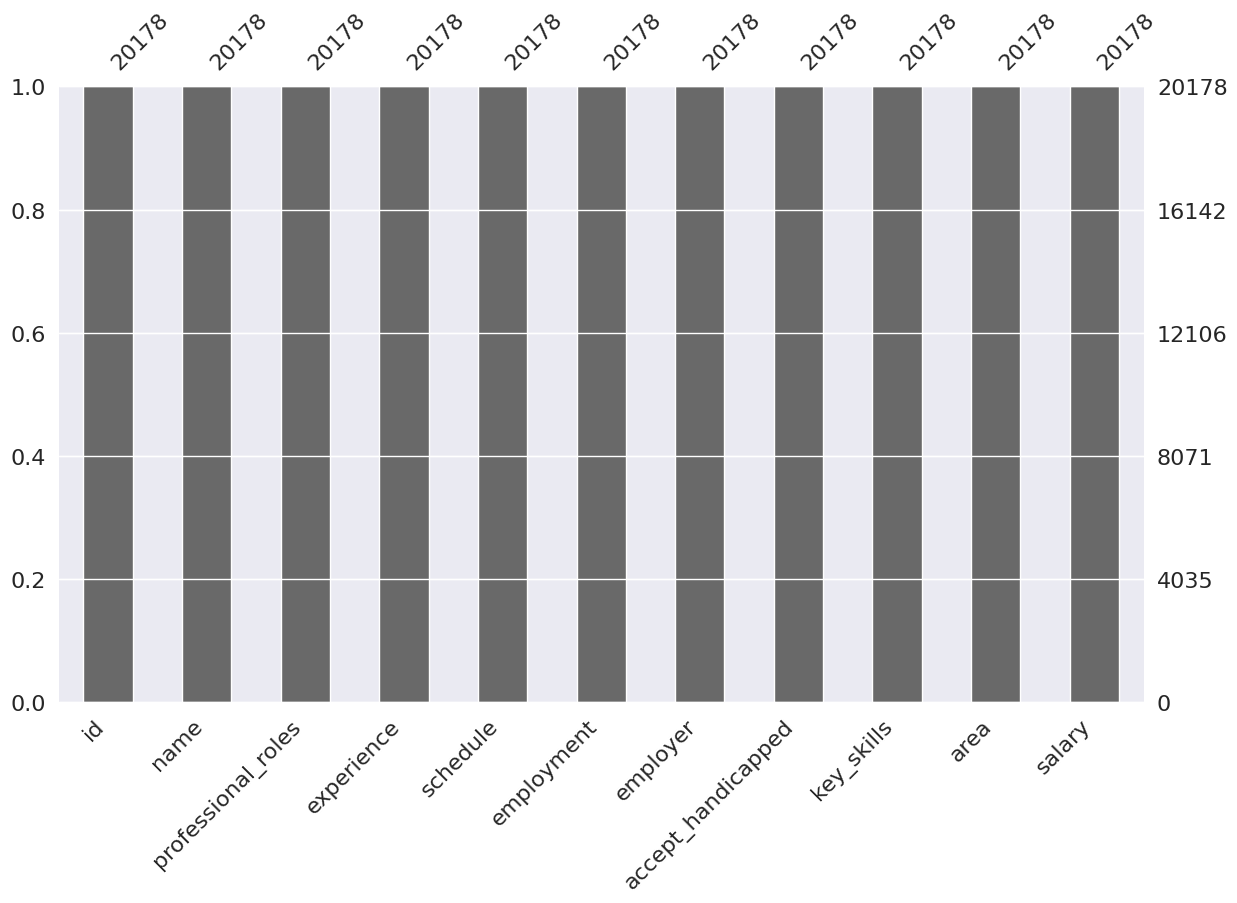

In [10]:
sns.set()
msno.bar(dataset, figsize=(14, 8))
plt.show()

Просмотрим информацию о датасете

In [11]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20178 entries, 0 to 20177
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  20178 non-null  int64 
 1   name                20178 non-null  object
 2   professional_roles  20178 non-null  object
 3   experience          20178 non-null  object
 4   schedule            20178 non-null  object
 5   employment          20178 non-null  object
 6   employer            20178 non-null  object
 7   accept_handicapped  20178 non-null  bool  
 8   key_skills          20178 non-null  object
 9   area                20178 non-null  object
 10  salary              20178 non-null  object
dtypes: bool(1), int64(1), object(9)
memory usage: 1.6+ MB


Выводы по предварительному осмотру:

* **О размерах датасета**:

  20178 строк (наблюдений), 11 столбцов (признаков)

* **О типах данных**:

  - Количественные признаки:

    * идентификатор вакансии (id)

    * заработная плата (salary)

  - Категориальные признаки:

    * наименование вакансии (name)

    * профессиональная роль (professional roles)

    * регион (area)

    * опыт работы (experience)

    * график работы (schedule)

    * тип занятости (employment)

    * наименование работодателя (employer)

    * доступна ли вакансия для соискателей с инвалидностью (accept_handicapped)

    * ключевые навыки (key_skills)


* **О дубликатах**:

  - Присутствуют полные дубликаты


* **О пропущенных значениях:**

  - Пропущенных значений нет ни в одном из признаков

  - Возможно на этапе обработки признаков появятся нулевые значения там, где их быть не должно

## 4. Предобработка данных

### 4.1 Весь датасет

Посмотрим на полные дубликаты

In [12]:
dataset[dataset.duplicated(keep=False)].sort_values(['id'])

,id,name,professional_roles,experience,schedule,employment,employer,accept_handicapped,key_skills,area,salary
7102,45216508,Грузчик в магазин,Грузчик,0,full_day,full,Томлад,False,['Работа в команде'],"{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":20000.0,""salary_to"":null}"
20119,45216508,Грузчик в магазин,Грузчик,0,full_day,full,Томлад,False,['Работа в команде'],"{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":20000.0,""salary_to"":null}"
20107,46759262,Разработчик C#,"Программист, разработчик",1-3,full_day,full,"СИБУР, Группа компаний",False,"['BPMN', 'C#/.NET', 'Creatio', 'Javascript', '...","{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":null,""salary_to"":null}"
12431,46759262,Разработчик C#,"Программист, разработчик",1-3,full_day,full,"СИБУР, Группа компаний",False,"['BPMN', 'C#/.NET', 'Creatio', 'Javascript', '...","{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":null,""salary_to"":null}"
20106,51940526,Python - программист / автоматизатор,"Программист, разработчик",1-3,full_day,full,ИнфоТеКС,False,"['Базовая работа с Linux', 'Базовая работа с L...","{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":null,""salary_to"":null}"
...,...,...,...,...,...,...,...,...,...,...,...
1083,97334218,Менеджер по продажам,"Менеджер по продажам, менеджер по работе с кли...",1-3,full_day,full,Баляева Анастасия Вениаминовна,False,"['Продажи', 'Продажи', 'Коммуникативная грамот...","{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":60000.0,""salary_to"":100000.0}"
20173,97589011,Обмотчик элементов электрических машин,Другое,1-3,full_day,full,РН-Ремонт НПО,False,['Знания в области электротехники'],"{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":118107.0,""salary_to"":null}"
5803,97589011,Обмотчик элементов электрических машин,Другое,1-3,full_day,full,РН-Ремонт НПО,False,['Знания в области электротехники'],"{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":118107.0,""salary_to"":null}"
12945,97782318,Стоматолог-терапевт,Врач,1-3,shift,part,Миродент,False,"['Грамотная речь', 'Публичные выступления и пр...","{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":150000.0,""salary_to"":null}"


Удалим полные дубликаты

In [13]:
dataset.drop_duplicates(inplace=True)

Заново проиндексируем датасет

In [14]:
dataset.reset_index(drop=True, inplace=True)

Проверим индексацию

In [15]:
dataset.index

RangeIndex(start=0, stop=20000, step=1)

Выведем информацию о датасете

In [16]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  20000 non-null  int64 
 1   name                20000 non-null  object
 2   professional_roles  20000 non-null  object
 3   experience          20000 non-null  object
 4   schedule            20000 non-null  object
 5   employment          20000 non-null  object
 6   employer            20000 non-null  object
 7   accept_handicapped  20000 non-null  bool  
 8   key_skills          20000 non-null  object
 9   area                20000 non-null  object
 10  salary              20000 non-null  object
dtypes: bool(1), int64(1), object(9)
memory usage: 1.5+ MB


### 4.2 Признак id

Запишем имя признака в переменную sign

In [17]:
sign = 'id'

Выведем признак для просмотра содержимого

In [18]:
dataset[sign].head(20)

,id
0,72121675
1,72121730
2,72122239
3,72123219
4,72123390
5,72124633
6,72124864
7,72125286
8,72125786
9,72125979


Выведем уникальные значения

In [19]:
pd.Series(dataset[sign].unique()).sample(20)

,0
16949,90030267
19874,84928880
9107,68763989
2482,93703032
16576,71749088
2525,85214481
7050,78441082
12710,66222813
5301,80507750
12566,76681313


Посмотрим наличие дубликатов

In [20]:
dataset.duplicated(subset=sign).sum()

np.int64(0)

**Выводы по обработке признака**:

* Аномалии не были найдены

* Размер датасета после обработки признака не изменился

* Тип данных признака не изменился

### 4.3 Признак name

Запишем имя признака в переменную sign

In [21]:
sign = 'name'

Удалим признак

In [22]:
dataset.drop(columns=sign, inplace=True)
dataset

,id,professional_roles,experience,schedule,employment,employer,accept_handicapped,key_skills,area,salary
0,72121675,"Инженер-конструктор, инженер-проектировщик",1-3,full_day,full,Стройкомплектсервис,False,"['ANSYS', 'AutoCAD', 'Autodesk Inventor', 'Sol...","{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":75000.0,""salary_to"":100000.0}"
1,72121730,Курьер,0,shift,part,Квазар,False,['Грамотная речь'],"{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":60000.0,""salary_to"":110000.0}"
2,72122239,"Менеджер по продажам, менеджер по работе с кли...",0,remote,part,Staff-Linear,True,"['Грамотная речь', 'Базовые знания ПК']","{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":25000.0,""salary_to"":50000.0}"
3,72123219,"Официант, бармен, бариста",0,shift,full,AYS GROUP,False,"['Грамотная речь', 'Грамотная речь', 'Работа в...","{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":null,""salary_to"":35000.0}"
4,72123390,"Повар, пекарь, кондитер",0,full_day,full,"ЛАМА, Группа компаний",False,"['Коммуникативная грамотность', 'Обучаемость и...","{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":28000.0,""salary_to"":36000.0}"
...,...,...,...,...,...,...,...,...,...,...
19995,69662481,"Оператор call-центра, специалист контактного ц...",0,full_day,full,Нужные Люди,False,"['Коммуникативная грамотность', 'Консультирова...","{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":27000.0,""salary_to"":30000.0}"
19996,69662486,Курьер,0,full_day,part,Кадровые Решения,False,"['Грамотная речь', 'Прием и оформление заказов...","{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":10000.0,""salary_to"":70000.0}"
19997,69663286,Курьер,0,full_day,part,Кадровые Решения,False,"['Грамотная речь', 'Прием и оформление заказов...","{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":10000.0,""salary_to"":70000.0}"
19998,69663857,Менеджер по закупкам,3-6,labor,full,Нефтегазовые технологии и инженерные изыскания,False,"['Многозадачность', 'Стрессоустойчивость', 'Ст...","{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":120000.0,""salary_to"":135000.0}"


Посмотрим информациб о датасете

In [23]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  20000 non-null  int64 
 1   professional_roles  20000 non-null  object
 2   experience          20000 non-null  object
 3   schedule            20000 non-null  object
 4   employment          20000 non-null  object
 5   employer            20000 non-null  object
 6   accept_handicapped  20000 non-null  bool  
 7   key_skills          20000 non-null  object
 8   area                20000 non-null  object
 9   salary              20000 non-null  object
dtypes: bool(1), int64(1), object(8)
memory usage: 1.4+ MB


**Выводы по обработке признака**:

* Аномалии не были найдены

* Размер датасета после обработки признака (20000, 10)

* Признак удалён

### 4.4 Признак professional_roles



Запишем имя признака в переменную sign

In [24]:
sign = 'professional_roles'

Выведем признак для просмотра содержимого

In [25]:
dataset[sign].head(30)

,professional_roles
0,"Инженер-конструктор, инженер-проектировщик"
1,Курьер
2,"Менеджер по продажам, менеджер по работе с кли..."
3,"Официант, бармен, бариста"
4,"Повар, пекарь, кондитер"
5,Технолог
6,Водитель
7,Электромонтажник
8,"Менеджер по продажам, менеджер по работе с кли..."
9,Агент по недвижимости


Выведем уникальные значения

In [26]:
pd.Series(dataset[sign].unique()).sample(20)

,0
135,Специалист по взысканию задолженности
127,PR-менеджер
18,"Автослесарь, автомеханик"
35,Оператор производственной линии
138,Продуктовый аналитик
119,"Генеральный директор, исполнительный директор ..."
21,Другое
31,Инженер по охране труда и технике безопасности...
117,Директор по персоналу (HRD)
113,"Фитнес-тренер, инструктор тренажерного зала"


Посмотрим количество уникальных значений

In [27]:
dataset[sign].unique().shape

(171,)

Приведём признак к типу string

In [28]:
dataset[sign] = dataset[sign].astype('string')

Проверим тип данных

In [29]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  20000 non-null  int64 
 1   professional_roles  20000 non-null  string
 2   experience          20000 non-null  object
 3   schedule            20000 non-null  object
 4   employment          20000 non-null  object
 5   employer            20000 non-null  object
 6   accept_handicapped  20000 non-null  bool  
 7   key_skills          20000 non-null  object
 8   area                20000 non-null  object
 9   salary              20000 non-null  object
dtypes: bool(1), int64(1), object(7), string(1)
memory usage: 1.4+ MB


**Выводы по обработке признака**:

* Аномалии не были найдены

* Размер датасета после обработки признака не изменился

* Тип данных признака приведён к string

### 4.5 Признак experience

Запишем имя признака в переменную sign

In [30]:
sign = 'experience'

Выведем признак для просмотра содержимого

In [31]:
dataset[sign].head(30)

,experience
0,1-3
1,0
2,0
3,0
4,0
5,1-3
6,0
7,3-6
8,1-3
9,0


Выведем уникальные значения

In [32]:
dataset[sign].unique()

array(['1-3', '0', '3-6', '6-'], dtype=object)

Приведём признак к типу category

In [33]:
dataset[sign] = dataset[sign].astype('category')

Осмотрим датасет

In [34]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   id                  20000 non-null  int64   
 1   professional_roles  20000 non-null  string  
 2   experience          20000 non-null  category
 3   schedule            20000 non-null  object  
 4   employment          20000 non-null  object  
 5   employer            20000 non-null  object  
 6   accept_handicapped  20000 non-null  bool    
 7   key_skills          20000 non-null  object  
 8   area                20000 non-null  object  
 9   salary              20000 non-null  object  
dtypes: bool(1), category(1), int64(1), object(6), string(1)
memory usage: 1.3+ MB


**Выводы по обработке признака**:

  * Аномалии не были найдены

  * Размер датасета после обработки признака не изменился
  
  * Тип данных признака приведён к category

### 4.6 Признак schedule

Запишем имя признака в переменную sign

In [35]:
sign = 'schedule'

Выведем признак для просмотра содержимого

In [36]:
dataset[sign].head(30)

,schedule
0,full_day
1,shift
2,remote
3,shift
4,full_day
5,full_day
6,full_day
7,labor
8,full_day
9,full_day


Выведем уникальные значения

In [37]:
dataset[sign].unique()

array(['full_day', 'shift', 'remote', 'labor', 'flexible'], dtype=object)

Приведём признак к типу category

In [38]:
dataset[sign] = dataset[sign].astype('category')

Осмотрим датасет

In [39]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   id                  20000 non-null  int64   
 1   professional_roles  20000 non-null  string  
 2   experience          20000 non-null  category
 3   schedule            20000 non-null  category
 4   employment          20000 non-null  object  
 5   employer            20000 non-null  object  
 6   accept_handicapped  20000 non-null  bool    
 7   key_skills          20000 non-null  object  
 8   area                20000 non-null  object  
 9   salary              20000 non-null  object  
dtypes: bool(1), category(2), int64(1), object(5), string(1)
memory usage: 1.1+ MB


**Выводы по обработке признака**:

  * Аномалии не были найдены

  * Размер датасета после обработки признака не изменился
  
  * Тип данных признака приведён к category

### 4.7 Признак employment

Запишем имя признака в переменную sign

In [40]:
sign = 'employment'

Выведем признак для просмотра содержимого

In [41]:
dataset[sign].head(30)

,employment
0,full
1,part
2,part
3,full
4,full
5,full
6,full
7,full
8,full
9,full


Выведем уникальные значения

In [42]:
dataset[sign].unique()

array(['full', 'part', 'project', 'probation'], dtype=object)

Приведём признак к типу category

In [43]:
dataset[sign] = dataset[sign].astype('category')

Осмотрим датасет

In [44]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   id                  20000 non-null  int64   
 1   professional_roles  20000 non-null  string  
 2   experience          20000 non-null  category
 3   schedule            20000 non-null  category
 4   employment          20000 non-null  category
 5   employer            20000 non-null  object  
 6   accept_handicapped  20000 non-null  bool    
 7   key_skills          20000 non-null  object  
 8   area                20000 non-null  object  
 9   salary              20000 non-null  object  
dtypes: bool(1), category(3), int64(1), object(4), string(1)
memory usage: 1016.4+ KB


**Выводы по обработке признака**:

  * Аномалии не были найдены

  * Размер датасета после обработки признака не изменился
  
  * Тип данных признака приведён к category

### 4.8 Признака employer

Запишем имя признака в переменную sign

In [45]:
sign = 'employer'

Выведем признак для просмотра содержимого

In [46]:
dataset[sign].head(30)

,employer
0,Стройкомплектсервис
1,Квазар
2,Staff-Linear
3,AYS GROUP
4,"ЛАМА, Группа компаний"
5,Деталь Проект
6,Автоцентр АВТОГИК
7,Эко-Системы
8,"Мототека, филиал г.Томск"
9,ДомПлюс


Выведем уникальные значения

In [47]:
pd.Series(dataset[sign].unique()).sample(20)

,0
3844,Центр разработки и внедрения
1975,TUT SОЧНО
2448,Петрол Групп
406,Поволжское Строительное Предприятие
739,Сибирское молоко
2888,ДорСтройПроект
736,Производственная Компания Шахановские Рыбные П...
4252,Центр Комплектации
790,Спутник
4022,Джекит


Приведём признак к типу string

In [48]:
dataset[sign] = dataset[sign].astype('string')

Проверим тип данных

In [49]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   id                  20000 non-null  int64   
 1   professional_roles  20000 non-null  string  
 2   experience          20000 non-null  category
 3   schedule            20000 non-null  category
 4   employment          20000 non-null  category
 5   employer            20000 non-null  string  
 6   accept_handicapped  20000 non-null  bool    
 7   key_skills          20000 non-null  object  
 8   area                20000 non-null  object  
 9   salary              20000 non-null  object  
dtypes: bool(1), category(3), int64(1), object(3), string(2)
memory usage: 1016.4+ KB


**Выводы по обработке признака**:

  * Аномалии не были найдены

  * Размер датасета после обработки признака не изменился

  * Тип данных признака приведён к string

### 4.9 Признак accept_handicapped

Запишем имя признака в переменную sign

In [50]:
sign = 'accept_handicapped'

Выведем признак для просмотра содержимого

In [51]:
dataset[sign].head(30)

,accept_handicapped
0,False
1,False
2,True
3,False
4,False
5,False
6,False
7,False
8,False
9,False


Выведем уникальные значения

In [52]:
dataset[sign].unique()

array([False,  True])

Приведём признак к типу category

In [53]:
dataset[sign] = dataset[sign].astype('Int64').astype('category')

Выведем информацию о датасете

In [54]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   id                  20000 non-null  int64   
 1   professional_roles  20000 non-null  string  
 2   experience          20000 non-null  category
 3   schedule            20000 non-null  category
 4   employment          20000 non-null  category
 5   employer            20000 non-null  string  
 6   accept_handicapped  20000 non-null  category
 7   key_skills          20000 non-null  object  
 8   area                20000 non-null  object  
 9   salary              20000 non-null  object  
dtypes: category(4), int64(1), object(3), string(2)
memory usage: 1016.5+ KB


**Выводы по обработке признака**:

  * Аномалии не были найдены

  * Размер датасета после обработки признака не изменился

  * Тип данных признака приведён к category

### 4.10 Признак key_skills

Запишем имя признака в переменную sign

In [55]:
sign = 'key_skills'

Выведем признак для просмотра содержимого

In [56]:
dataset[sign].head(30)

,key_skills
0,"['ANSYS', 'AutoCAD', 'Autodesk Inventor', 'Sol..."
1,['Грамотная речь']
2,"['Грамотная речь', 'Базовые знания ПК']"
3,"['Грамотная речь', 'Грамотная речь', 'Работа в..."
4,"['Коммуникативная грамотность', 'Обучаемость и..."
5,"['Ведение документооборота', 'Базовые знания П..."
6,"['Базовые знания ПК', 'Коммуникативная грамотн..."
7,"['Монтаж металлоконструкций', 'Выполнение стро..."
8,"['Продажи', 'Коммуникативная грамотность', 'Гр..."
9,"['Продажи', 'Продажи', 'Коммуникативная грамот..."


Выведем уникальные значения

In [57]:
dataset[sign].unique()

array(["['ANSYS', 'AutoCAD', 'Autodesk Inventor', 'SolidWorks', 'Разработка конструкторской документации', 'КОМПАС-3D', 'Разработка проектной документации', 'Разработка чертежей']",
       "['Грамотная речь']", "['Грамотная речь', 'Базовые знания ПК']",
       ...,
       "['Коммуникативная грамотность', 'Консультирование и ведение клиентов', 'Ведение документооборота']",
       "['Многозадачность', 'Стрессоустойчивость', 'Стрессоустойчивость']",
       "['Продажи', 'Грамотная речь', 'Коммуникативная грамотность', 'Информационная грамотность', 'Целеустремленность и работоспособность', 'Работа в команде', 'Коммуникативная грамотность', 'Продажи']"],
      dtype=object)

Посмотрим на количество уникальных значений

In [58]:
dataset[sign].unique().shape

(11476,)

Изменим структуру признака

In [59]:
dataset[sign] = dataset[sign].apply(ast.literal_eval)
dataset = dataset.explode(sign)
dataset

,id,professional_roles,experience,schedule,employment,employer,accept_handicapped,key_skills,area,salary
0,72121675,"Инженер-конструктор, инженер-проектировщик",1-3,full_day,full,Стройкомплектсервис,0,ANSYS,"{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":75000.0,""salary_to"":100000.0}"
0,72121675,"Инженер-конструктор, инженер-проектировщик",1-3,full_day,full,Стройкомплектсервис,0,AutoCAD,"{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":75000.0,""salary_to"":100000.0}"
0,72121675,"Инженер-конструктор, инженер-проектировщик",1-3,full_day,full,Стройкомплектсервис,0,Autodesk Inventor,"{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":75000.0,""salary_to"":100000.0}"
0,72121675,"Инженер-конструктор, инженер-проектировщик",1-3,full_day,full,Стройкомплектсервис,0,SolidWorks,"{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":75000.0,""salary_to"":100000.0}"
0,72121675,"Инженер-конструктор, инженер-проектировщик",1-3,full_day,full,Стройкомплектсервис,0,Разработка конструкторской документации,"{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":75000.0,""salary_to"":100000.0}"
...,...,...,...,...,...,...,...,...,...,...
19999,69669507,"Менеджер по продажам, менеджер по работе с кли...",0,full_day,full,Везибензин,0,Информационная грамотность,"{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":28000.0,""salary_to"":35000.0}"
19999,69669507,"Менеджер по продажам, менеджер по работе с кли...",0,full_day,full,Везибензин,0,Целеустремленность и работоспособность,"{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":28000.0,""salary_to"":35000.0}"
19999,69669507,"Менеджер по продажам, менеджер по работе с кли...",0,full_day,full,Везибензин,0,Работа в команде,"{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":28000.0,""salary_to"":35000.0}"
19999,69669507,"Менеджер по продажам, менеджер по работе с кли...",0,full_day,full,Везибензин,0,Коммуникативная грамотность,"{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":28000.0,""salary_to"":35000.0}"


Выведем уникальные значения

In [60]:
dataset[sign].unique()

array(['ANSYS', 'AutoCAD', 'Autodesk Inventor', 'SolidWorks',
       'Разработка конструкторской документации', 'КОМПАС-3D',
       'Разработка проектной документации', 'Разработка чертежей',
       'Грамотная речь', 'Базовые знания ПК', 'Работа в команде',
       'Коммуникативная грамотность', 'Обучаемость и адаптивность',
       'Коучинг и проведение тренингов', 'Организаторские навыки',
       'Продажи', 'Ведение документооборота', 'Прием груза',
       'Погрузочно-разгрузочные работы',
       'Учет товарно-материальных ценностей', 'Монтаж металлоконструкций',
       'Выполнение строительно-монтажных работ',
       'Выполнение ремонтных работ', 'Составление договоров',
       'Поиск и привлечение новых клиентов',
       'Публичные выступления и проведение презентаций',
       'Управление и планирование продаж', 'Работа с жилой недвижимостью',
       'Microsoft Outlook', 'Microsoft PowerPoint', 'ГРАНД-Смета',
       'Разработка сметной документации', 'Чтение чертежей',
       'Целеус

Посмотрим на количество уникальных значений

In [61]:
dataset[sign].unique().shape

(846,)

Приведём признак к типу string

In [62]:
dataset[sign] = dataset[sign].astype('string')

Удалим появившиеся дубликаты

In [63]:
display(dataset.duplicated(keep="first").sum())
dataset.drop_duplicates(inplace=True)

np.int64(18081)

Посмотрим информацию о датасете

In [64]:
dataset.reset_index(drop=True, inplace=True)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81412 entries, 0 to 81411
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   id                  81412 non-null  int64   
 1   professional_roles  81412 non-null  string  
 2   experience          81412 non-null  category
 3   schedule            81412 non-null  category
 4   employment          81412 non-null  category
 5   employer            81412 non-null  string  
 6   accept_handicapped  81412 non-null  category
 7   key_skills          81412 non-null  string  
 8   area                81412 non-null  object  
 9   salary              81412 non-null  object  
dtypes: category(4), int64(1), object(2), string(3)
memory usage: 4.0+ MB


**Выводы по обработке признака**:

  * Раньше признак содержал строки, представляющие собой списки, а теперь в каждом наблюдении хранится только один навык

  * После обработки признака размер датасета стал (81411, 10)

  * Тип данных признака - string

### 4.11 Признак area

Запишем имя признака в переменную sign

In [65]:
sign = 'area'

Выведем признак для просмотра содержимого

In [66]:
dataset[sign].head(30)

,area
0,"{""country"":""Россия"",""region"":""Томская область""..."
1,"{""country"":""Россия"",""region"":""Томская область""..."
2,"{""country"":""Россия"",""region"":""Томская область""..."
3,"{""country"":""Россия"",""region"":""Томская область""..."
4,"{""country"":""Россия"",""region"":""Томская область""..."
5,"{""country"":""Россия"",""region"":""Томская область""..."
6,"{""country"":""Россия"",""region"":""Томская область""..."
7,"{""country"":""Россия"",""region"":""Томская область""..."
8,"{""country"":""Россия"",""region"":""Томская область""..."
9,"{""country"":""Россия"",""region"":""Томская область""..."


Напишем парсер для нашего признака

In [67]:
def parse_area(area_str: str) -> pd.Series:
    """
    Парсит строку с JSON-данными о местоположении и извлекает страну, регион и город.

    :param area_str: Строка в формате JSON, содержащая данные о местоположении.
    :return: Pandas Series, содержащий страну, регион и город
    """
    area_dict = json.loads(area_str)
    return pd.Series([area_dict.get('country'),
                      area_dict.get('region'),
                      area_dict.get('district'),
                      area_dict.get('city')
                      ])

Присоединим новые признаки к датасету

In [68]:
dataset[['country', 'region', 'district', 'city']] = dataset[sign].apply(parse_area)
dataset

,id,professional_roles,experience,schedule,employment,employer,accept_handicapped,key_skills,area,salary,country,region,district,city
0,72121675,"Инженер-конструктор, инженер-проектировщик",1-3,full_day,full,Стройкомплектсервис,0,ANSYS,"{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":75000.0,""salary_to"":100000.0}",Россия,Томская область,Сибирский,Томск
1,72121675,"Инженер-конструктор, инженер-проектировщик",1-3,full_day,full,Стройкомплектсервис,0,AutoCAD,"{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":75000.0,""salary_to"":100000.0}",Россия,Томская область,Сибирский,Томск
2,72121675,"Инженер-конструктор, инженер-проектировщик",1-3,full_day,full,Стройкомплектсервис,0,Autodesk Inventor,"{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":75000.0,""salary_to"":100000.0}",Россия,Томская область,Сибирский,Томск
3,72121675,"Инженер-конструктор, инженер-проектировщик",1-3,full_day,full,Стройкомплектсервис,0,SolidWorks,"{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":75000.0,""salary_to"":100000.0}",Россия,Томская область,Сибирский,Томск
4,72121675,"Инженер-конструктор, инженер-проектировщик",1-3,full_day,full,Стройкомплектсервис,0,Разработка конструкторской документации,"{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":75000.0,""salary_to"":100000.0}",Россия,Томская область,Сибирский,Томск
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81407,69669507,"Менеджер по продажам, менеджер по работе с кли...",0,full_day,full,Везибензин,0,Грамотная речь,"{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":28000.0,""salary_to"":35000.0}",Россия,Томская область,Сибирский,Томск
81408,69669507,"Менеджер по продажам, менеджер по работе с кли...",0,full_day,full,Везибензин,0,Коммуникативная грамотность,"{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":28000.0,""salary_to"":35000.0}",Россия,Томская область,Сибирский,Томск
81409,69669507,"Менеджер по продажам, менеджер по работе с кли...",0,full_day,full,Везибензин,0,Информационная грамотность,"{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":28000.0,""salary_to"":35000.0}",Россия,Томская область,Сибирский,Томск
81410,69669507,"Менеджер по продажам, менеджер по работе с кли...",0,full_day,full,Везибензин,0,Целеустремленность и работоспособность,"{""country"":""Россия"",""region"":""Томская область""...","{""salary_from"":28000.0,""salary_to"":35000.0}",Россия,Томская область,Сибирский,Томск


Удалим обработанный признак

In [69]:
dataset.drop(sign, axis=1, inplace=True)

Приведём новые признаки к типу string

In [70]:
dataset[['country', 'region', 'district', 'city']] = dataset[['country', 'region', 'district', 'city']].astype('string')

Посмотрим информацию о датасете

In [71]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81412 entries, 0 to 81411
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   id                  81412 non-null  int64   
 1   professional_roles  81412 non-null  string  
 2   experience          81412 non-null  category
 3   schedule            81412 non-null  category
 4   employment          81412 non-null  category
 5   employer            81412 non-null  string  
 6   accept_handicapped  81412 non-null  category
 7   key_skills          81412 non-null  string  
 8   salary              81412 non-null  object  
 9   country             81412 non-null  string  
 10  region              81412 non-null  string  
 11  district            81412 non-null  string  
 12  city                81412 non-null  string  
dtypes: category(4), int64(1), object(1), string(7)
memory usage: 5.9+ MB


**Выводы по обработке признака**:

  * Признак имел вложенную структуру. В него были вложены другие признаки

  * После обработки признака выросло количество признаков с 10 до 13, количество наблюдений не изменилось

  * Признак был удалён

  * Тип данных признаков приведён к string

### 4.12 Признак country

Запишем имя признака в переменную sign

In [72]:
sign = 'country'

Выведем признак для просмотра содержимого

In [73]:
dataset[sign].head(30)

,country
0,Россия
1,Россия
2,Россия
3,Россия
4,Россия
5,Россия
6,Россия
7,Россия
8,Россия
9,Россия


Выведем уникальные значения

In [74]:
dataset[sign].unique()

<StringArray>
['Россия']
Length: 1, dtype: string

Вследствие малой информативности признака удалим его

In [75]:
dataset.drop(columns=sign, inplace=True)

Посмотрим информацию о датасете

In [76]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81412 entries, 0 to 81411
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   id                  81412 non-null  int64   
 1   professional_roles  81412 non-null  string  
 2   experience          81412 non-null  category
 3   schedule            81412 non-null  category
 4   employment          81412 non-null  category
 5   employer            81412 non-null  string  
 6   accept_handicapped  81412 non-null  category
 7   key_skills          81412 non-null  string  
 8   salary              81412 non-null  object  
 9   region              81412 non-null  string  
 10  district            81412 non-null  string  
 11  city                81412 non-null  string  
dtypes: category(4), int64(1), object(1), string(6)
memory usage: 5.3+ MB


**Выводы по обработке признака**:

* Признак оказался не информативным. Cодержал только одно значение

* После обработки признака выросло количество признаков с 13 до 12, количество наблюдений не изменилось

* Признак был удалён

### 4.13 Признак region

Запишем имя признака в переменную sign

In [77]:
sign = 'region'

Выведем признак для просмотра содержимого

In [78]:
dataset[sign].head(30)

,region
0,Томская область
1,Томская область
2,Томская область
3,Томская область
4,Томская область
5,Томская область
6,Томская область
7,Томская область
8,Томская область
9,Томская область


Выведите уникальные значения с помощью метода unique()

In [79]:
dataset[sign].unique()

<StringArray>
['Томская область']
Length: 1, dtype: string

Вследствие малой информативности признака удалим его

In [80]:
dataset.drop(columns=sign, inplace=True)

Посмотрим информацию о датасете

In [81]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81412 entries, 0 to 81411
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   id                  81412 non-null  int64   
 1   professional_roles  81412 non-null  string  
 2   experience          81412 non-null  category
 3   schedule            81412 non-null  category
 4   employment          81412 non-null  category
 5   employer            81412 non-null  string  
 6   accept_handicapped  81412 non-null  category
 7   key_skills          81412 non-null  string  
 8   salary              81412 non-null  object  
 9   district            81412 non-null  string  
 10  city                81412 non-null  string  
dtypes: category(4), int64(1), object(1), string(5)
memory usage: 4.7+ MB


**Выводы по обработке признака**:

* Признак оказался не информативным. Cодержал только одно значение

* После обработки признака выросло количество признаков с 12 до 11, количество наблюдений не изменилось

* Признак был удалён

### 4.14 Признак district

Запишем имя признака в переменную sign

In [82]:
sign = 'district'

Выведем признак для просмотра содержимого

In [83]:
dataset[sign].head(30)

,district
0,Сибирский
1,Сибирский
2,Сибирский
3,Сибирский
4,Сибирский
5,Сибирский
6,Сибирский
7,Сибирский
8,Сибирский
9,Сибирский


Выведите уникальные значения с помощью метода unique()

In [84]:
dataset[sign].unique()

<StringArray>
['Сибирский']
Length: 1, dtype: string

Вследствие малой информативности признака удалим его

In [85]:
dataset.drop(columns=sign, inplace=True)

Посмотрим информацию о датасете

In [86]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81412 entries, 0 to 81411
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   id                  81412 non-null  int64   
 1   professional_roles  81412 non-null  string  
 2   experience          81412 non-null  category
 3   schedule            81412 non-null  category
 4   employment          81412 non-null  category
 5   employer            81412 non-null  string  
 6   accept_handicapped  81412 non-null  category
 7   key_skills          81412 non-null  string  
 8   salary              81412 non-null  object  
 9   city                81412 non-null  string  
dtypes: category(4), int64(1), object(1), string(4)
memory usage: 4.0+ MB


**Выводы по обработке признака**:

* Признак оказался не информативным. Cодержал только одно значение

* После обработки признака выросло количество признаков с 11 до 10, количество наблюдений не изменилось

* Признак был удалён

### 4.15 Признак city

Запишем имя признака в переменную sign

In [87]:
sign = 'city'

Выведем признак для просмотра содержимого

In [88]:
dataset[sign].head(30)

,city
0,Томск
1,Томск
2,Томск
3,Томск
4,Томск
5,Томск
6,Томск
7,Томск
8,Томск
9,Томск


Выведем уникальные значения

In [89]:
dataset[sign].unique()

<StringArray>
[                            'Томск',                          'Могочино',
                           'Каргала',    'Первомайское (Томская область)',
                           'Чажемто',                            'Самусь',
                         'Колпашево',                          'Рыбалово',
                            'Парбиг',                          'Копылово',
                            'Курлек',                          'Кедровый',
                        'Кривошеино',                          'Кисловка',
                            'Бакчар',                          'Богашёво',
         'Северск (Томская область)',         'Светлый (Томская область)',
                         'Стрежевой',                          'Белый Яр',
                         'Молчаново',                         'Подгорное',
                        'Мельниково',                             'Асино',
                          'Каргасок',                         'Тегульдет',
           

Посмотрим информацию о датасете

In [90]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81412 entries, 0 to 81411
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   id                  81412 non-null  int64   
 1   professional_roles  81412 non-null  string  
 2   experience          81412 non-null  category
 3   schedule            81412 non-null  category
 4   employment          81412 non-null  category
 5   employer            81412 non-null  string  
 6   accept_handicapped  81412 non-null  category
 7   key_skills          81412 non-null  string  
 8   salary              81412 non-null  object  
 9   city                81412 non-null  string  
dtypes: category(4), int64(1), object(1), string(4)
memory usage: 4.0+ MB


**Выводы по обработке признака**:

* Аномалии не были найдены

* Размер датасета после обработки признака не изменился

* Тип данных признака не изменился

### 4.16 Признак salary

Запишем имя признака в переменную sign

In [91]:
sign = 'salary'

Выведем признак для просмотра содержимого

In [92]:
dataset[sign].head(30)

,salary
0,"{""salary_from"":75000.0,""salary_to"":100000.0}"
1,"{""salary_from"":75000.0,""salary_to"":100000.0}"
2,"{""salary_from"":75000.0,""salary_to"":100000.0}"
3,"{""salary_from"":75000.0,""salary_to"":100000.0}"
4,"{""salary_from"":75000.0,""salary_to"":100000.0}"
5,"{""salary_from"":75000.0,""salary_to"":100000.0}"
6,"{""salary_from"":75000.0,""salary_to"":100000.0}"
7,"{""salary_from"":75000.0,""salary_to"":100000.0}"
8,"{""salary_from"":60000.0,""salary_to"":110000.0}"
9,"{""salary_from"":25000.0,""salary_to"":50000.0}"


Напишем парсер для нашего признака

In [93]:
def parse_salary(salary_str: str) -> pd.Series:
    """
    Парсит строку с JSON-данными о зарплате и извлекает минимальную и максимальную ЗП.

    :param salary_str: Строка в формате JSON, содержащая данные о зарплате.
    :return: Pandas Series с полями `salary_from` и `salary_to` (тип float, NaN если данных нет).
    """
    if pd.isna(salary_str) or not salary_str.strip():
        return pd.Series([float('nan'), float('nan')])

    salary_dict = json.loads(salary_str)
    return pd.Series([
        salary_dict.get('salary_from'),
        salary_dict.get('salary_to'),
    ])

Присоединим новые признаки к датасету

In [94]:
dataset[['salary_from', 'salary_to']] = dataset[sign].apply(parse_salary)
dataset

,id,professional_roles,experience,schedule,employment,employer,accept_handicapped,key_skills,salary,city,salary_from,salary_to
0,72121675,"Инженер-конструктор, инженер-проектировщик",1-3,full_day,full,Стройкомплектсервис,0,ANSYS,"{""salary_from"":75000.0,""salary_to"":100000.0}",Томск,75000.0,100000.0
1,72121675,"Инженер-конструктор, инженер-проектировщик",1-3,full_day,full,Стройкомплектсервис,0,AutoCAD,"{""salary_from"":75000.0,""salary_to"":100000.0}",Томск,75000.0,100000.0
2,72121675,"Инженер-конструктор, инженер-проектировщик",1-3,full_day,full,Стройкомплектсервис,0,Autodesk Inventor,"{""salary_from"":75000.0,""salary_to"":100000.0}",Томск,75000.0,100000.0
3,72121675,"Инженер-конструктор, инженер-проектировщик",1-3,full_day,full,Стройкомплектсервис,0,SolidWorks,"{""salary_from"":75000.0,""salary_to"":100000.0}",Томск,75000.0,100000.0
4,72121675,"Инженер-конструктор, инженер-проектировщик",1-3,full_day,full,Стройкомплектсервис,0,Разработка конструкторской документации,"{""salary_from"":75000.0,""salary_to"":100000.0}",Томск,75000.0,100000.0
...,...,...,...,...,...,...,...,...,...,...,...,...
81407,69669507,"Менеджер по продажам, менеджер по работе с кли...",0,full_day,full,Везибензин,0,Грамотная речь,"{""salary_from"":28000.0,""salary_to"":35000.0}",Томск,28000.0,35000.0
81408,69669507,"Менеджер по продажам, менеджер по работе с кли...",0,full_day,full,Везибензин,0,Коммуникативная грамотность,"{""salary_from"":28000.0,""salary_to"":35000.0}",Томск,28000.0,35000.0
81409,69669507,"Менеджер по продажам, менеджер по работе с кли...",0,full_day,full,Везибензин,0,Информационная грамотность,"{""salary_from"":28000.0,""salary_to"":35000.0}",Томск,28000.0,35000.0
81410,69669507,"Менеджер по продажам, менеджер по работе с кли...",0,full_day,full,Везибензин,0,Целеустремленность и работоспособность,"{""salary_from"":28000.0,""salary_to"":35000.0}",Томск,28000.0,35000.0


Удалим обработанный признак

In [95]:
dataset.drop(sign, axis=1, inplace=True)

Приведём новые признаки к типу string

In [96]:
dataset[['salary_from', 'salary_to']] = dataset[['salary_from', 'salary_to']].astype('Int64')

Посмотрим информацию о датасете

In [97]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81412 entries, 0 to 81411
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   id                  81412 non-null  int64   
 1   professional_roles  81412 non-null  string  
 2   experience          81412 non-null  category
 3   schedule            81412 non-null  category
 4   employment          81412 non-null  category
 5   employer            81412 non-null  string  
 6   accept_handicapped  81412 non-null  category
 7   key_skills          81412 non-null  string  
 8   city                81412 non-null  string  
 9   salary_from         64380 non-null  Int64   
 10  salary_to           39947 non-null  Int64   
dtypes: Int64(2), category(4), int64(1), string(4)
memory usage: 4.8 MB


**Выводы по обработке признака**:

  * Признак имел вложенную структуру. В него были вложены другие признаки
  
  * В самом признаке пропущенные значения отсутсвуют, но в вложенных в него они есть

  * После обработки признака выросло количество признаков с 10 до 11, количество наблюдений не изменилось

  * Признак был обработан и удалён

  * Тип данных вложенных признаков приведён к Int64

### 4.17 Признаки salary_from и salary_to

Запишем имена признаков в переменный sign_1 и sign_2

In [98]:
sign_1, sign_2 = 'salary_from', 'salary_to'

Выведем признаки для просмотра содержимого

In [99]:
dataset[[sign_1, sign_2]].head(30)

,salary_from,salary_to
0,75000,100000
1,75000,100000
2,75000,100000
3,75000,100000
4,75000,100000
5,75000,100000
6,75000,100000
7,75000,100000
8,60000,110000
9,25000,50000


Выведем уникальные значения

In [100]:
display(f"Признак {sign_1}:")
display(dataset[sign_1].unique())
display(f"Признак {sign_2}:")
dataset[sign_2].unique()

'Признак salary_from:'

<IntegerArray>
[ 75000,  60000,  25000,   <NA>,  28000,  35000, 100000,  40000,  80000,
  42760,
 ...
  22080,  62345,  72645, 124320,  69900,  44585,  26840,  58400,  53400,
  40207]
Length: 704, dtype: Int64

'Признак salary_to:'

<IntegerArray>
[100000, 110000,  50000,  35000,  36000,  60000,  85000, 150000,  95000,
   <NA>,
 ...
 205700,  33500, 115543,  90800, 380000,  68400,  44585,  26840,  59100,
  50148]
Length: 615, dtype: Int64

Выведем количество уникальных значений

In [101]:
dataset[sign_1].unique().shape, dataset[sign_2].unique().shape

((704,), (615,))

В признаках были обнаружены пропущенные значения

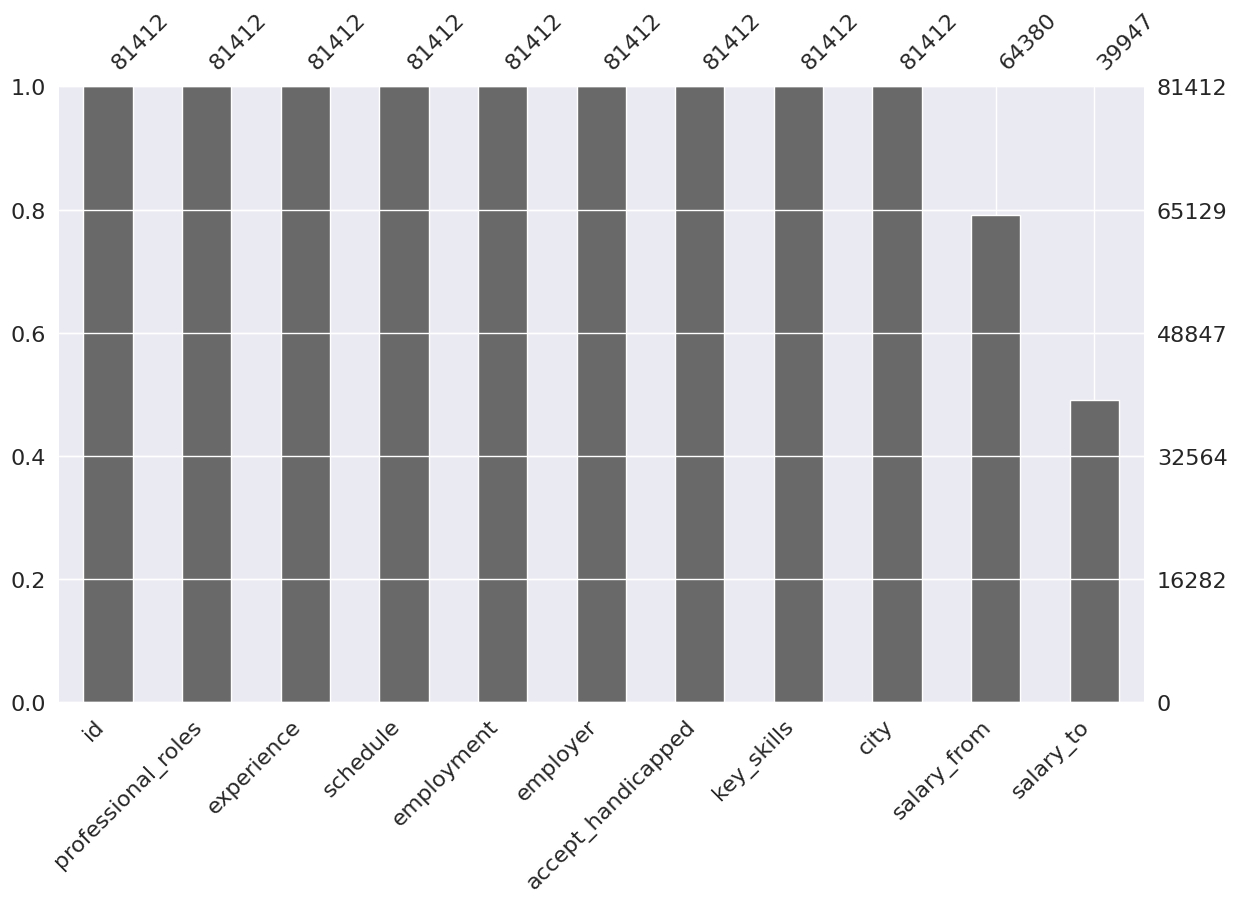

In [102]:
sns.set()
msno.bar(dataset, figsize=(14, 8))
plt.show()

Построим матрицу пропущенных значений

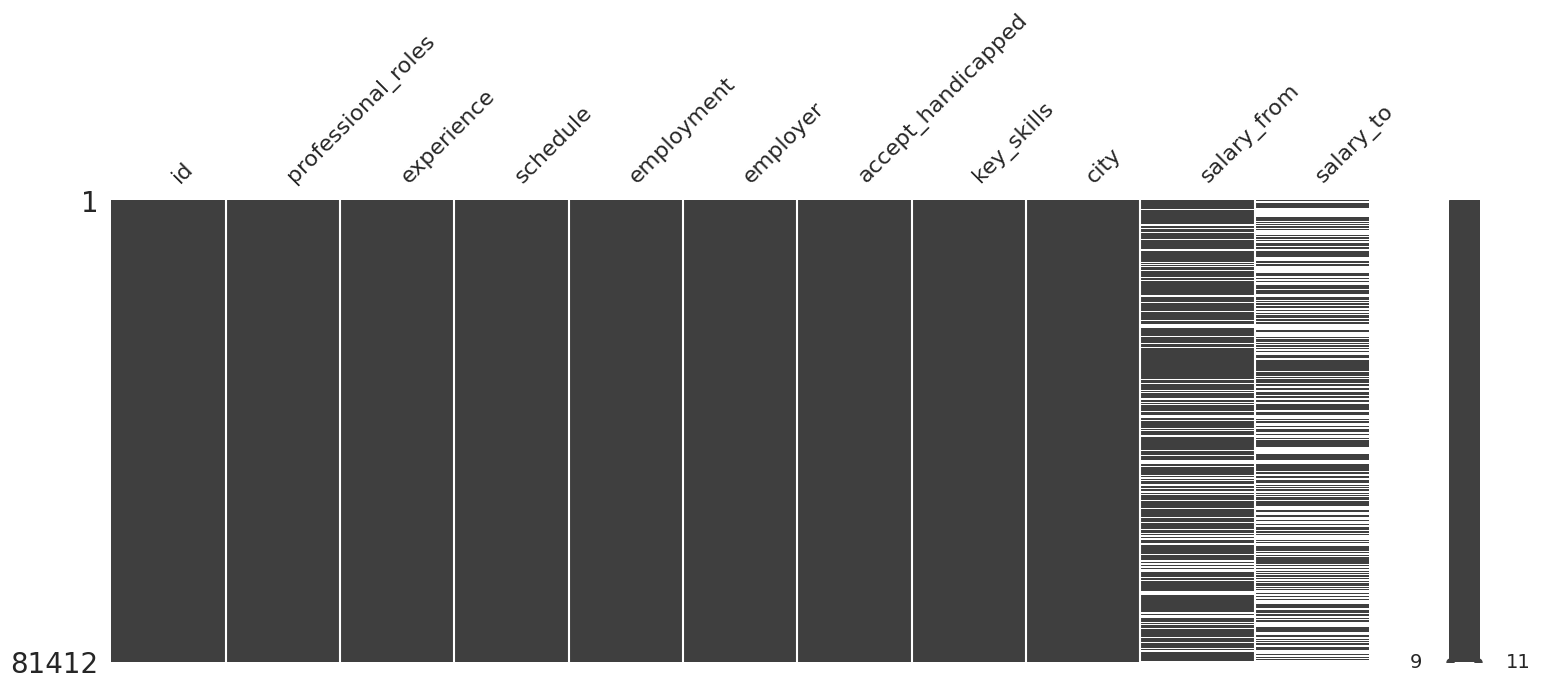

In [103]:
msno.matrix(dataset, figsize=(18, 6))
plt.show()

Построим матрицу корреляций пропущенных значений

In [104]:
dataset[[sign_1, sign_2]].isnull().corr()

,salary_from,salary_to
salary_from,1.00000,0.33238
salary_to,0.33238,1.00000


Отобразим матрицу корреляций

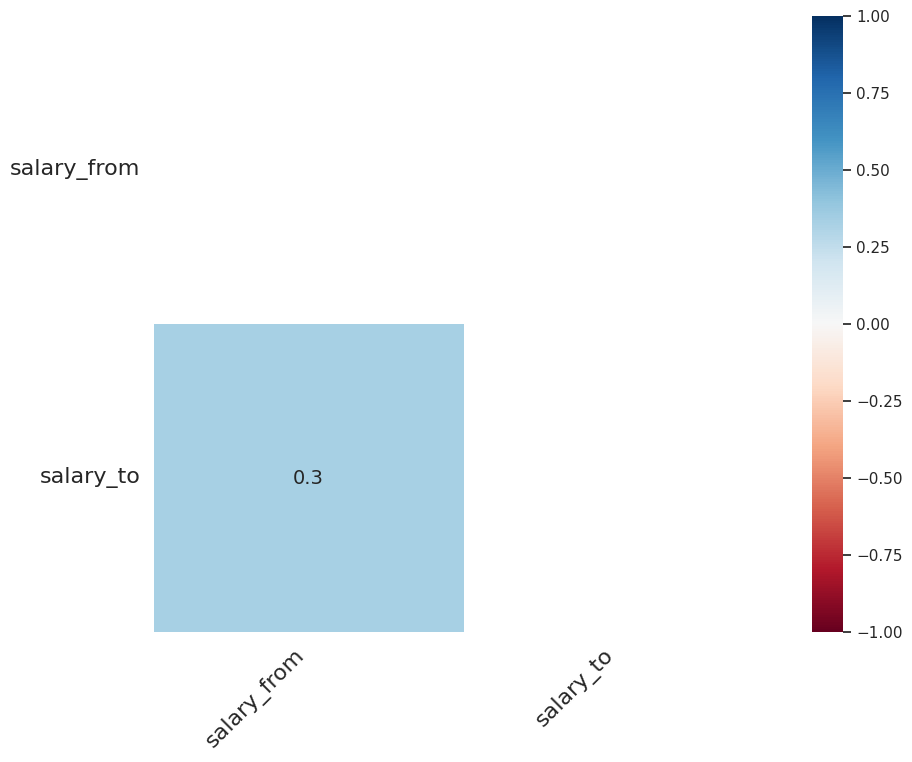

In [105]:
msno.heatmap(dataset[[sign_1, sign_2]], figsize=(10, 8))
plt.show()

Для каждой профессии найдём медианную, среднюю, минимальную, максимальную зарплаты и количество наблюдений по ней

In [106]:
statistics = dataset.groupby("professional_roles")[[sign_1, sign_2]].agg(['median', 'mean', 'min', 'max', 'count'])
statistics.head(30)

salary_from                 \
                                                        median           mean   
professional_roles                                                              
BI-аналитик, аналитик данных                           50000.0   71090.909091   
DevOps-инженер                                        300000.0       237500.0   
Event-менеджер                                         20000.0   27857.142857   
PR-менеджер                                            40000.0   46666.666667   
SMM-менеджер, контент-менеджер                         28000.0    30247.38676   
Автомойщик                                             40000.0    41728.15534   
Автослесарь, автомеханик                               50000.0   63438.169388   
Агент по недвижимости                                  55000.0   66501.466276   
Агроном                                                50000.0        55120.0   
Администратор                                          27000.0   28372.001953   
Администратор магазина, администратор торгового...     45000.0   48387.639881   
Аналитик                                               43000.0   64038.306452   
Андеррайтер                                            43000.0        41800.0   
Арт-директор, креативный директор                      42000.0   66076.923077   
Артист, актер, аниматор                                20000.0   35217.391304   
Архитектор                                             60000.0   56496.703297   
Ассистент врача                                        30000.0   31196.341463   
Аудитор                                                40000.0   38589.285714   
Бизнес-аналитик                                        30000.0        36900.0   
Бизнес-тренер                                          34500.0   42738.481013   
Брокер                                                 40000.0        40000.0   
Бухгалтер                                              37000.0   41064.308483   
Ветеринарный врач                                      60000.0   50070.731707   
Видеооператор, видеомонтажер                           45000.0   48255.813953   
Водитель                                               66600.0   78598.736739   
Военнослужащий                                         42500.0        42500.0   
Воспитатель, няня                                      23000.0   23222.863636   
Врач                                                   55000.0   65224.408163   
Гейм-дизайнер                                          60000.0        60000.0   
Генеральный директор, исполнительный директор (...    120000.0  139393.939394   

                                                                          \
                                                       min     max count   
professional_roles                                                         
BI-аналитик, аналитик данных                         18000  140000    11   
DevOps-инженер                                      150000  300000    24   
Event-менеджер                                       20000   40000    28   
PR-менеджер                                          25000   70000    57   
SMM-менеджер, контент-менеджер                        5000   80000   287   
Автомойщик                                           16000  100000   103   
Автослесарь, автомеханик                             20000  220000   490   
Агент по недвижимости                                20000  200000   341   
Агроном                                              25000  100000    50   
Администратор                                           15  120000  2048   
Администратор магазина, администратор торгового...   18000   80000   336   
Аналитик                                               500  300000   248   
Андеррайтер                                          40000   43000    10   
Арт-директор, креативный директор                    42000  120000    26   
Артист, актер, аниматор                              10000   60000    23   
Архитекто

Подготовим модели для заполнения пропусков по методу K-ближайших

In [107]:
def prepare_knn_imputer(dataset: pd.DataFrame, target_column: str, n_neighbors: int = 5) -> KNNImputer:
    """
    Обучает KNN-импутер для заполнения пропусков в указанном столбце
    :param dataset: Исходный датафрейм с данными
    :param target_column: Название столбца, для которого обучается импутер
    :param n_neighbors: Количество соседей для KNN
    :return: Обученный импутер для указанного столбца
    """
    known_values = dataset[dataset[target_column].notna()][[target_column]]  # Берём только известные значения
    known_values = known_values.values.reshape(-1, 1)  # Преобразуем в 2D-массив (требование KNNImputer)
    imputer = KNNImputer(n_neighbors=n_neighbors)  # Создаём импутер
    imputer.fit(known_values)  # Обучаем на известных данных

    return imputer

knn_imputer_sign_1 = prepare_knn_imputer(dataset, sign_1)  # Для признака 1
knn_imputer_sign_2 = prepare_knn_imputer(dataset, sign_2)  # Для признака 2

Проведем сравнительный анализ распределения, сравнив датасеты с пропусками, заполненными медианными и средними значениями, а также с исходным датасетом, содержащим пропуски.

In [108]:
# Создаем копии датасета для заполнения
dataset_by_median = dataset[['professional_roles', sign_1, sign_2]].copy()
dataset_by_mean = dataset[['professional_roles', sign_1, sign_2]].copy()

for role in dataset['professional_roles'].unique():
    # Маски для групп
    median_mask = dataset_by_median['professional_roles'] == role
    mean_mask = dataset_by_mean['professional_roles'] == role

    # Получение статистик из DataFrame statistics
    median_sign_1 = statistics.loc[role, (sign_1, 'median')] if role in statistics.index else np.nan
    median_sign_2 = statistics.loc[role, (sign_2, 'median')] if role in statistics.index else np.nan
    mean_sign_1 = statistics.loc[role, (sign_1, 'mean')] if role in statistics.index else np.nan
    mean_sign_2 = statistics.loc[role, (sign_2, 'mean')] if role in statistics.index else np.nan

    # Обработка для sign_1 (медиана)
    if pd.isna(median_sign_1):
        # Для KNN нужно передать 2D массив
        knn_value = knn_imputer_sign_1.transform([[np.nan]])[0][0]
        dataset_by_median.loc[median_mask, sign_1] = dataset_by_median.loc[median_mask, sign_1].fillna(int(knn_value))
    else:
        dataset_by_median.loc[median_mask, sign_1] = dataset_by_median.loc[median_mask, sign_1].fillna(int(median_sign_1))

    # Обработка для sign_2 (медиана)
    if pd.isna(median_sign_2):
        knn_value = knn_imputer_sign_2.transform([[np.nan]])[0][0]
        dataset_by_median.loc[median_mask, sign_2] = dataset_by_median.loc[median_mask, sign_2].fillna(int(knn_value))
    else:
        dataset_by_median.loc[median_mask, sign_2] = dataset_by_median.loc[median_mask, sign_2].fillna(int(median_sign_2))

    # Обработка для sign_1 (среднее)
    if pd.isna(mean_sign_1):
        knn_value = knn_imputer_sign_1.transform([[np.nan]])[0][0]
        dataset_by_mean.loc[mean_mask, sign_1] = dataset_by_mean.loc[mean_mask, sign_1].fillna(int(knn_value))
    else:
        dataset_by_mean.loc[mean_mask, sign_1] = dataset_by_mean.loc[mean_mask, sign_1].fillna(int(mean_sign_1))

    # Обработка для sign_2 (среднее)
    if pd.isna(mean_sign_2):
        knn_value = knn_imputer_sign_2.transform([[np.nan]])[0][0]
        dataset_by_mean.loc[mean_mask, sign_2] = dataset_by_mean.loc[mean_mask, sign_2].fillna(int(knn_value))
    else:
        dataset_by_mean.loc[mean_mask, sign_2] = dataset_by_mean.loc[mean_mask, sign_2].fillna(int(mean_sign_2))

Графический анализ по sign_1

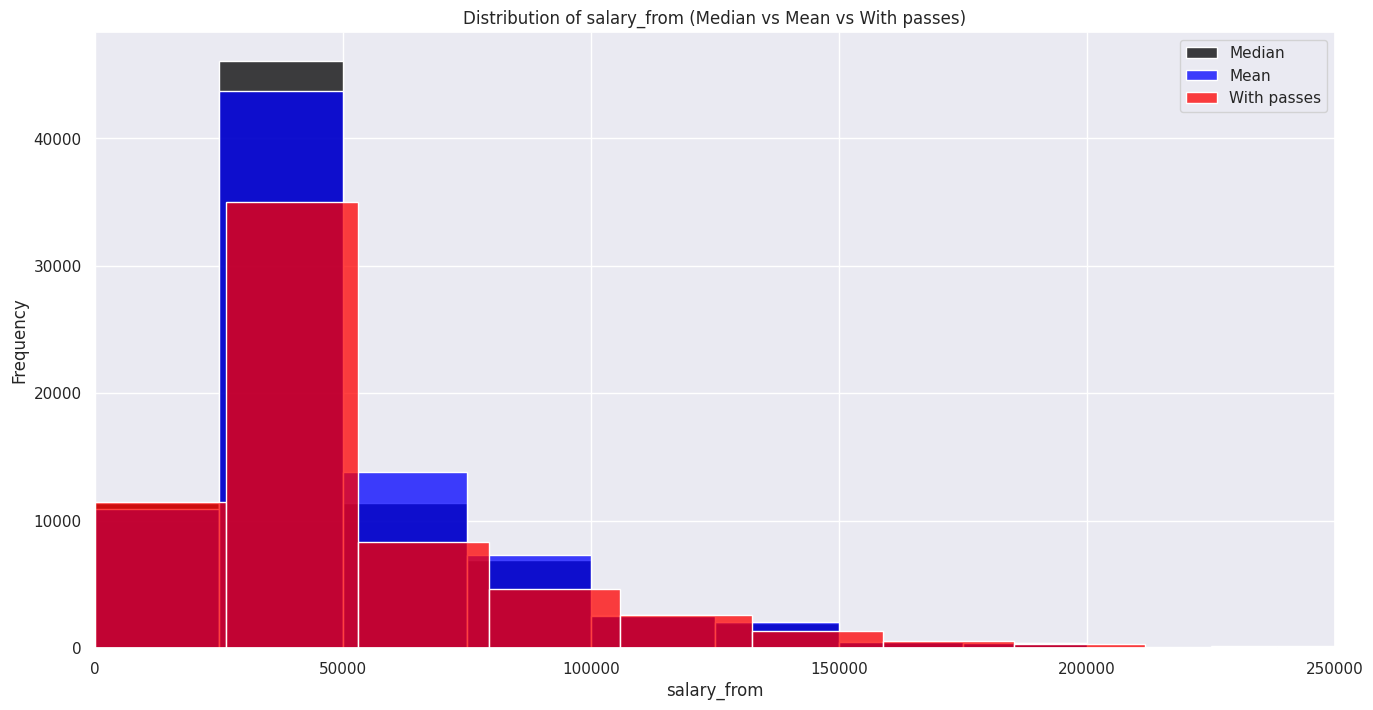

In [109]:
plt.figure(figsize=(16, 8))
sns.histplot(dataset_by_median[sign_1], bins='sturges', color='black', label='Median', kde=False)
sns.histplot(dataset_by_mean[sign_1], bins='sturges', color='blue', label='Mean', kde=False)
sns.histplot(dataset[sign_1], bins='sturges', color='red', label='With passes', kde=False)
plt.xlim(0, 250000)
plt.xlabel(sign_1)
plt.ylabel('Frequency')
plt.title('Distribution of ' + sign_1 + ' (Median vs Mean vs With passes)')
plt.legend()
plt.show()

Графический анализ по sign_2

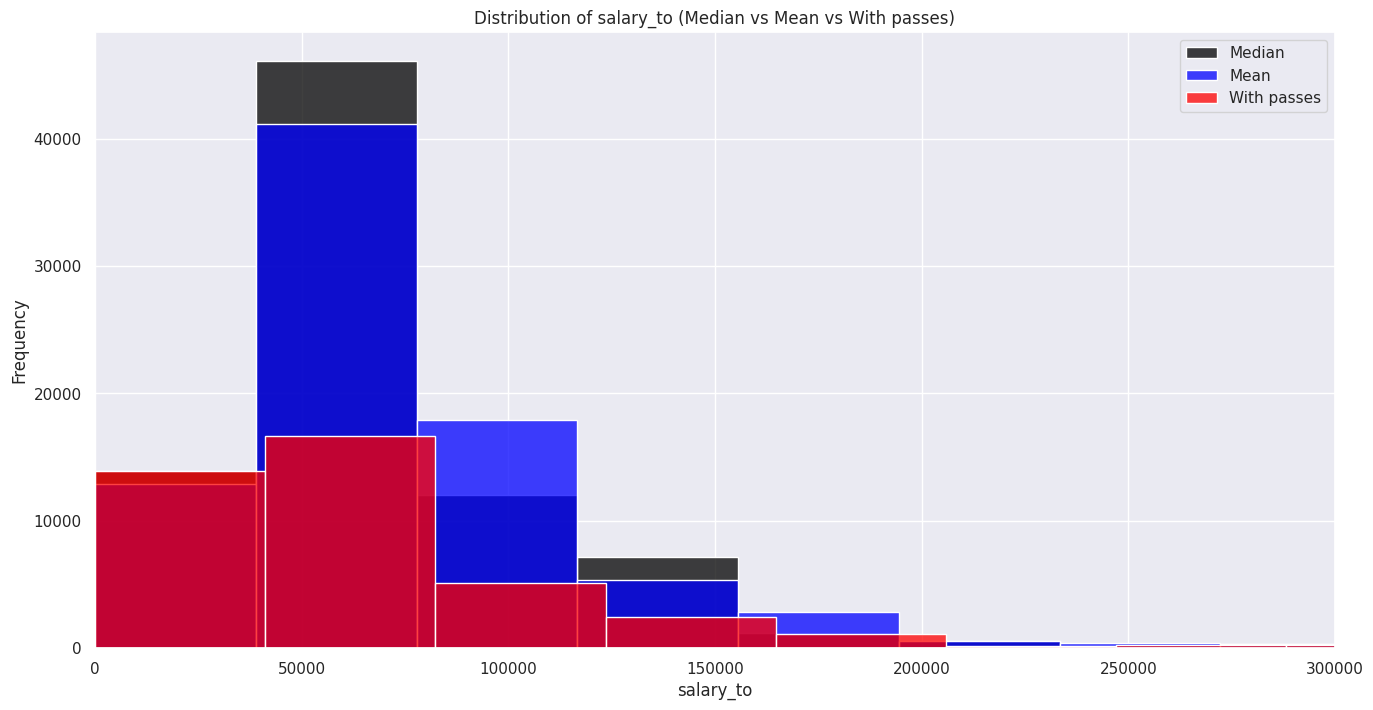

In [110]:
plt.figure(figsize=(16, 8))
sns.histplot(dataset_by_median[sign_2], bins='sturges', color='black', label='Median', kde=False)
sns.histplot(dataset_by_mean[sign_2], bins='sturges', color='blue', label='Mean', kde=False)
sns.histplot(dataset[sign_2], bins='sturges', color='red', label='With passes', kde=False)
plt.xlim(0, 300000)
plt.xlabel(sign_2)
plt.ylabel('Frequency')
plt.title('Distribution of ' + sign_2 + ' (Median vs Mean vs With passes)')
plt.legend()
plt.show()

Заполним с помощью среднего пропуски по минимальной ЗП и максимальной ЗП

In [111]:
dataset[[sign_1, sign_2]] = dataset_by_mean[[sign_1, sign_2]].copy()

Посмотрим нет ли наблюдений в которых минимальная зарплата больше, чем максимальная

In [112]:
dataset[dataset[sign_1] > dataset[sign_2]][[sign_1, sign_2]]

,salary_from,salary_to
115,90000,53591
116,90000,53591
117,90000,53591
192,105000,60702
193,105000,60702
...,...,...
81381,51469,50369
81382,51469,50369
81383,51469,50369
81384,51469,50369


Поменяем местами, если есть такие строки

In [113]:
mask = dataset[sign_1] > dataset[sign_2]
dataset.loc[mask, [sign_1, sign_2]] = dataset.loc[mask, [sign_2, sign_1]].values

Проверим нет ли теперь наблюдений в которых минимальная зарплата больше, чем максимальная

In [114]:
dataset[dataset[sign_1] > dataset[sign_2]][[sign_1, sign_2]]

,salary_from,salary_to


Посмотрим информацию о датасете

In [115]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81412 entries, 0 to 81411
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   id                  81412 non-null  int64   
 1   professional_roles  81412 non-null  string  
 2   experience          81412 non-null  category
 3   schedule            81412 non-null  category
 4   employment          81412 non-null  category
 5   employer            81412 non-null  string  
 6   accept_handicapped  81412 non-null  category
 7   key_skills          81412 non-null  string  
 8   city                81412 non-null  string  
 9   salary_from         81412 non-null  Int64   
 10  salary_to           81412 non-null  Int64   
dtypes: Int64(2), category(4), int64(1), string(4)
memory usage: 4.8 MB


**Выводы по обработке признака**:

  * В признаках salary_from и salary_to обнаружены пропущенные значения

  * Матрица пропущенных значений и тепловая карта корреляции показали, что пропуски в этих признаках могут быть слабо связаны между собой

  * Для каждой профессии (professional_roles) были рассчитаны медианные, средние, минимальные, максимальные значения и количество наблюдений

  * Это позволило заполнить пропуски на основе групповых статистик, что является более точным, чем общее среднее или медиана по всему датасету

  * KNN Imputer: Для профессий, по которым не было достаточных данных, применялся метод ближайших соседей

  * Обнаружены и исправлены строки, где salary_from (минимальная зарплата) была больше salary_to (максимальной зарплаты). В таких случаях значения были поменяны местами

  * После обработки аномальных строк не осталось


### 4.18 Признак field_of_activity

Запишем имена признаков в переменный sign_1 и sign_2

In [116]:
sign_1, sign_2 = 'field_of_activity', 'professional_roles'

Создадим словарь со сферами деятельности

In [117]:
role_to_field = {
    'Инженерия и строительство': (
        'Инженер-конструктор, инженер-проектировщик',
        'Инженер ПТО, инженер-сметчик',
        'Главный инженер проекта',
        'Инженер по эксплуатации',
        'Инженер по охране труда и технике безопасности, инженер-эколог',
        'Инженер по качеству',
        'Инженер ПНР',
        'Инженер-энергетик, инженер-электрик',
        'Инженер-электроник, инженер-электронщик',
        'Сервисный инженер, инженер-механик',
        'Архитектор',
        'Прораб, мастер СМР',
        'Геодезист',
        'Руководитель строительного проекта',
        'Электромонтажник',
        'Системный инженер'
    ),

    'IT и технологии': (
        'Программист, разработчик',
        'Тестировщик',
        'Системный администратор',
        'Сетевой инженер',
        'DevOps-инженер',
        'Технический писатель',
        'Специалист по информационной безопасности',
        'Руководитель группы разработки',
        'Системный аналитик',
        'Бизнес-аналитик',
        'Дата-сайентист',
        'Гейм-дизайнер',
        'BI-аналитик, аналитик данных',
        'Технический директор (CTO)',
        'Директор по информационным технологиям (CIO)',
        'Оператор ПК, оператор базы данных'
    ),

    'Производство и технические специальности': (
        'Технолог',
        'Слесарь, сантехник',
        'Автослесарь, автомеханик',
        'Сварщик',
        'Токарь, фрезеровщик, шлифовщик',
        'Механик',
        'Мастер по ремонту оборудования, техники',
        'Оператор станков с ЧПУ',
        'Оператор производственной линии',
        'Маляр, штукатур',
        'Монтажник',
        'Метролог',
        'Контролёр ОТК',
        'Начальник производства',
        'Начальник смены, мастер участка',
        'Специалист по сертификации'
    ),

    'Транспорт и логистика': (
        'Водитель',
        'Машинист',
        'Диспетчер',
        'Менеджер по логистике, менеджер по ВЭД',
        'Руководитель отдела логистики',
        'Курьер'
    ),

    'Торговля и продажи': (
        'Менеджер по продажам, менеджер по работе с клиентами',
        'Продавец-консультант, продавец-кассир',
        'Торговый представитель',
        'Мерчандайзер',
        'Координатор отдела продаж',
        'Руководитель отдела продаж',
        'Коммерческий директор (CCO)',
        'Администратор магазина, администратор торгового зала',
        'Директор магазина, директор сети магазинов',
        'Кассир-операционист',
        'Товаровед',
        'Агент по недвижимости',
        'Брокер',
        'Страховой агент'
    ),

    'Финансы и бухгалтерия': (
        'Бухгалтер',
        'Экономист',
        'Финансовый директор (CFO)',
        'Финансовый аналитик, инвестиционный аналитик',
        'Финансовый менеджер',
        'Аудитор',
        'Казначей',
        'Кредитный специалист',
        'Андеррайтер',
        'Специалист по взысканию задолженности',
        'Финансовый контролер',
        'Экономики и финансов',
    ),

    'Маркетинг и реклама': (
        'Менеджер по маркетингу, интернет-маркетолог',
        'SMM-менеджер, контент-менеджер',
        'PR-менеджер',
        'Event-менеджер',
        'Копирайтер, редактор, корректор',
        'Директор по маркетингу и PR (CMO)',
        'Маркетолог-аналитик',
        'Арт-директор, креативный директор',
        'Руководитель отдела маркетинга и рекламы',
        'Промоутер'
    ),

    'Управление и администрирование': (
        'Менеджер по персоналу',
        'Специалист по подбору персонала',
        'Директор по персоналу (HRD)',
        'Руководитель отдела персонала',
        'Бизнес-тренер',
        'Менеджер/руководитель АХО',
        'Офис-менеджер',
        'Секретарь, помощник руководителя, ассистент',
        'Делопроизводитель, архивариус',
        'Специалист по кадрам',
        'Менеджер по компенсациям и льготам',
        'Менеджер по работе с партнерами',
        'Генеральный директор, исполнительный директор (CEO)',
        'Операционный директор (COO)',
        'Руководитель проектов',
        'Руководитель филиала',
        'Супервайзер',
        'Менеджер продукта',
        'Специалист по тендерам',
        'Менеджер по закупкам'

    ),

    'Аналитика и исследования': (
        'Аналитик',
        'Продуктовый аналитик',
        'Руководитель отдела аналитики'
    ),

    'Медицина и фармацевтика': (
        'Врач',
        'Медицинская сестра, медицинский брат',
        'Фармацевт-провизор',
        'Заведующий аптекой',
        'Косметолог',
        'Массажист',
        'Ветеринарный врач',
        'Ассистент врача',
        'Главный врач, заведующий отделением',
        'Медицинский представитель'
    ),

    'Образование и наука': (
        'Учитель, преподаватель, педагог',
        'Воспитатель, няня',
        'Методист',
        'Научный специалист, исследователь',
        'Психолог',
        'Методолог',
        'Лаборант'

    ),

    'Юриспруденция и безопасность': (
        'Юрист',
        'Юрисконсульт',
        'Директор юридического департамента (CLO)',
        'Специалист службы безопасности',
        'Охранник',
        'Полицейский',
        'Военнослужащий'
    ),

    'Творчество и медиа': (
        'Дизайнер, художник',
        'Видеооператор, видеомонтажер',
        'Фотограф, ретушер',
        'Журналист, корреспондент',
        'Режиссер, сценарист',
        'Артист, актер, аниматор',
        'Продюсер',
        'Переводчик'
    ),

    'Сфера обслуживания': (
        'Официант, бармен, бариста',
        'Повар, пекарь, кондитер',
        'Менеджер ресторана',
        'Хостес',
        'Администратор',
        'Мастер-приемщик',
        'Оператор call-центра, специалист контактного центра',
        'Специалист технической поддержки',
        'Руководитель отдела клиентского обслуживания',
        'Оценщик'
    ),

    'Сельское хозяйство': (
        'Агроном',
        'Зоотехник',
        'Геолог'
    ),

    'Склад и грузоперевозки': (
        'Кладовщик',
        'Начальник склада',
        'Разнорабочий',
        'Упаковщик, комплектовщик',
        'Грузчик'
    ),

    'Бытовые услуги': (
        'Швея, портной, закройщик',
        'Парикмахер',
        'Мастер ногтевого сервиса',
        'Автомойщик',
        'Уборщица, уборщик',
        'Дворник'
    ),

    'Спорт и фитнес': (
        'Фитнес-тренер, инструктор тренажерного зала',
    ),

    'Туризм': (
        'Менеджер по туризму',
    ),

    'Другие сферы': (
        'Другое',
    )
}


Создадим функцию для распределения профессий по сферам в датасете

In [118]:
def map_role_to_field(role: str) -> str:
    """Сопоставляет профессию со сферой деятельности."""
    for field, roles in role_to_field.items():
        if role in roles:
            return field
    return "Другие сферы"  # Если профессия не найдена

Применим функцию к датасету

In [119]:
dataset[sign_1] = dataset[sign_2].apply(map_role_to_field)

Приведём признак к типу category

In [120]:
dataset[sign_1] = dataset[sign_1].astype('category')

Посмотрим инфомрацию о датасете

In [121]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81412 entries, 0 to 81411
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   id                  81412 non-null  int64   
 1   professional_roles  81412 non-null  string  
 2   experience          81412 non-null  category
 3   schedule            81412 non-null  category
 4   employment          81412 non-null  category
 5   employer            81412 non-null  string  
 6   accept_handicapped  81412 non-null  category
 7   key_skills          81412 non-null  string  
 8   city                81412 non-null  string  
 9   salary_from         81412 non-null  Int64   
 10  salary_to           81412 non-null  Int64   
 11  field_of_activity   81412 non-null  category
dtypes: Int64(2), category(5), int64(1), string(4)
memory usage: 4.9 MB


**Выводы по обработке признака**:

  * Аномалии не были найдены

  * После создания признака выросло количество признаков с 11 до 12, количество наблюдений не изменилось

  * Тип данных признака приведён к category

## 5. Датасет после предобработки. Признаки, которые будут использованы для дальнейшего анализа:

Количественные признаки:
  
  - идентификатор вакансии (id)

  - минимальная заработная плат (salary_from)
  
  - максимальная заработная плата (salary_to)

Категориальные признаки:

  - профессиональная роль (professional roles)

  - ключевые навыки (key_skills)

  - наименование работодателя (employer)

  - опыт работы (experience)

  - график работы (schedule)

  - тип занятости (employment)

  - доступна ли вакансия для соискателей с инвалидностью (accept_handicapped)

  - город (city)

  - сфера деятельности (field_of_activity)

Посмотрим на размеры датасета

In [122]:
dataset.shape

(81412, 12)

Посмотрим информацию о датасете

In [123]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81412 entries, 0 to 81411
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   id                  81412 non-null  int64   
 1   professional_roles  81412 non-null  string  
 2   experience          81412 non-null  category
 3   schedule            81412 non-null  category
 4   employment          81412 non-null  category
 5   employer            81412 non-null  string  
 6   accept_handicapped  81412 non-null  category
 7   key_skills          81412 non-null  string  
 8   city                81412 non-null  string  
 9   salary_from         81412 non-null  Int64   
 10  salary_to           81412 non-null  Int64   
 11  field_of_activity   81412 non-null  category
dtypes: Int64(2), category(5), int64(1), string(4)
memory usage: 4.9 MB


Посмотрим количество пропусков в датасете

In [124]:
dataset.isnull().sum()

,0
id,0
professional_roles,0
experience,0
schedule,0
employment,0
employer,0
accept_handicapped,0
key_skills,0
city,0
salary_from,0
